# Gaussian stochastic master equation for a continuously monitored mode network

This notebook solves the **stochastic master equation (SME)** for an $N$-mode bosonic
network with quadratic Hamiltonian, linear damping into Markovian baths, and continuous
general-dyne (here heterodyne) monitoring of the output fields.

For Gaussian states the SME closes on the first two moments:

* the **conditional covariance matrix** $\sigma$ obeys a *deterministic* Riccati equation,
  and its steady state is the stabilising solution of a continuous algebraic Riccati
  equation (CARE);
* the **conditional mean** $\bar r$ obeys a linear Itô SDE driven by the measurement
  innovations.

See [`SOLUTION.md`](SOLUTION.md) for the derivation and conventions.
Conventions: quadratures in interleaved order $r=(x_1,p_1,\dots,x_N,p_N)^T$,
$x=a+a^\dagger$, $p=i(a^\dagger-a)$, so the vacuum has $\sigma=\mathbb 1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from pathlib import Path
from scipy.linalg import block_diag, sqrtm, solve_continuous_are, solve_continuous_lyapunov
from scipy.integrate import solve_ivp

np.set_printoptions(precision=4, suppress=True, linewidth=120)

## 1. Gaussian-state helpers

In [2]:
def symplectic_form(n_modes):
    # Omega for interleaved (x1, p1, x2, p2, ...) ordering
    return np.kron(np.eye(n_modes), np.array([[0, 1], [-1, 0]]))


def canonicalM(N):
    # Maps (a_1..a_n, a_1^dag..a_n^dag) -> interleaved (x_1, p_1, ..., x_n, p_n), n = N/2
    if N % 2 != 0:
        raise ValueError("Matrix dimension N must be even.")
    matrix = np.zeros((N, N), dtype=complex)
    mid = N // 2
    matrix[0, 0] = 1
    matrix[0, mid] = 1
    matrix[1, 0] = -1j
    matrix[1, mid] = 1j
    for i in range(2, N, 2):
        matrix[i] = np.roll(matrix[i - 2], 1)
        matrix[i + 1] = np.roll(matrix[i - 1], 1)
    return matrix


def two_mode_cm(CM, i, j):
    # 4x4 covariance matrix of the modes whose x-quadratures sit at indices i and j
    idx = [i, i + 1, j, j + 1]
    return CM[np.ix_(idx, idx)]


def log_negativity(CM):
    # Logarithmic negativity (base 2) of a 4x4 two-mode covariance matrix
    A, B, AB = CM[0:2, 0:2], CM[2:4, 2:4], CM[0:2, 2:4]
    delta = np.linalg.det(A) + np.linalg.det(B) - 2 * np.linalg.det(AB)
    nu_minus_sq = delta / 2 - np.sqrt(delta**2 - 4 * np.linalg.det(CM)) / 2
    return max(-np.log2(nu_minus_sq) / 2, 0)


def purity(CM):
    return 1 / np.sqrt(np.linalg.det(CM))


def symplectic_eigenvalues(CM):
    Omega = symplectic_form(CM.shape[0] // 2)
    return np.sort(np.abs(np.linalg.eigvals(1j * Omega @ CM)))[::2]


def pairwise_map(CM, f):
    # Matrix of f(two-mode CM) over all mode pairs (diagonal = NaN)
    n = CM.shape[0] // 2
    out = np.full((n, n), np.nan)
    for i, j in combinations(range(n), 2):
        out[i, j] = out[j, i] = f(two_mode_cm(CM, 2 * i, 2 * j))
    return out

## 2. Model: Hamiltonian, damping and monitoring

The Hamiltonian is $\hat H=\tfrac12\hat r^T H \hat r$ (with $H$ real symmetric), built from

* **two-mode squeezing** on the edges of a graph with complex weights $r_k e^{i\theta_k}$
  (a real weight gives $x_ip_j+p_ix_j$),
* an optional **beam splitter** between all pairs of modes ($p_ix_j-x_ip_j$).

Each mode couples to its own bath through $C=\bigoplus_j \sqrt{\kappa_j}\,\Omega_1^T$
(so mode $j$ decays at rate $\kappa_j$).

In [3]:
def build_adj(edges, weights, node_index, N):
    A = np.zeros((N, N), dtype=complex)
    for edge, w in zip(edges, weights):
        if w != 0:
            i, j = node_index[edge[0]], node_index[edge[1]]
            A[i, j] += w
            A[j, i] += w  # undirected graph
    return A


def squeezing_hamiltonian(adj):
    # Quadrature Hamiltonian matrix of the two-mode-squeezing graph `adj` (complex, symmetric)
    K = canonicalM(2 * adj.shape[0])
    H = K @ block_diag(1j * adj, -1j * np.conj(adj)) @ K.T / 2
    assert np.allclose(H.imag, 0)
    return H.real


def beamsplitter_hamiltonian_allpairs(n_modes):
    # Beam splitter between ALL pairs (k, m), k < m, in interleaved ordering
    H = np.zeros((2 * n_modes, 2 * n_modes))
    for k, m in combinations(range(n_modes), 2):
        x_k, p_k, x_m, p_m = 2 * k, 2 * k + 1, 2 * m, 2 * m + 1
        H[x_k, p_m] = H[p_m, x_k] = -1
        H[p_k, x_m] = H[x_m, p_k] = 1
    return H


def generaldyne_cm(n_modes, s=1.0, phi=0.0):
    # Measurement CM per mode: R(phi) diag(s, 1/s) R(phi)^T. s=1: heterodyne; s->0: homodyne of x_phi
    R = np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])
    return np.kron(np.eye(n_modes), R @ np.diag([s, 1 / s]) @ R.T)

## 3. Solvers

`sme_matrices` returns the drift $A$, diffusion $D$ and the monitoring matrices $B$, $E$.
With them the conditional dynamics reads

$$
\dot\sigma = A\sigma+\sigma A^T + D-(E-\sigma B)(E-\sigma B)^T, \qquad
d\bar r = A\bar r\,dt + (E-\sigma B)\,dW .
$$

**Note on `scipy.linalg.solve_continuous_are(a, b, q, r)`:** it solves
$a^TX+Xa-XBR^{-1}B^TX+Q=0$, so the drift must be passed **transposed**,
`a = Ã.T` with $\tilde A=A+EB^T$. (The original script passed `Ã`, which solves the
Riccati equation of the time-reversed drift; Sec. 5 checks this explicitly.)

In [4]:
def sme_matrices(H, C, sigma_in, sigma_m):
    # Drift A, diffusion D and general-dyne monitoring matrices B, E (see SOLUTION.md)
    Omega = symplectic_form(H.shape[0] // 2)
    A = Omega @ H + (Omega @ C) @ Omega @ C.T / 2
    D = (Omega @ C) @ sigma_in @ (Omega @ C).T
    S = np.real(sqrtm(np.linalg.inv(sigma_in + sigma_m)))
    B = C @ Omega @ S
    E = Omega @ C @ sigma_in @ S
    return A, D, B, E


def riccati_rhs(sigma, A, D, B, E):
    G = E - sigma @ B
    return A @ sigma + sigma @ A.T + D - G @ G.T


def steady_conditional_cm(A, D, B, E):
    # Stabilising solution of  Ã σ + σ Ã^T + (D - E E^T) - σ B B^T σ = 0,  Ã = A + E B^T
    At = A + E @ B.T
    sigma = solve_continuous_are(At.T, B, D - E @ E.T, np.eye(B.shape[1]), balanced=True)
    return 0.5 * (sigma + sigma.T)


def steady_unconditional_cm(A, D):
    # Lyapunov equation  A σ + σ A^T + D = 0  (no measurement / averaged over records)
    return solve_continuous_lyapunov(A, -D)


def riccati_trajectory(sigma0, A, D, B, E, t_max, n_t=400):
    # Time-dependent conditional covariance from sigma0
    n = sigma0.shape[0]
    rhs = lambda t, y: riccati_rhs(y.reshape(n, n), A, D, B, E).ravel()
    t = np.linspace(0, t_max, n_t)
    sol = solve_ivp(rhs, (0, t_max), sigma0.ravel(), t_eval=t, rtol=1e-9, atol=1e-11)
    return sol.t, sol.y.T.reshape(-1, n, n)


def mean_trajectory(r0, sigma0, A, D, B, E, t_max, dt, rng):
    # Euler–Maruyama for the conditional mean, with sigma(t) integrated alongside (Euler)
    n_steps = int(round(t_max / dt))
    r, sigma = r0.astype(float).copy(), sigma0.copy()
    rs = np.empty((n_steps + 1, r.size))
    rs[0] = r
    for k in range(n_steps):
        G = E - sigma @ B
        dW = rng.normal(scale=np.sqrt(dt), size=B.shape[1])
        r = r + A @ r * dt + G @ dW
        sigma = sigma + riccati_rhs(sigma, A, D, B, E) * dt
        rs[k + 1] = r
    return np.arange(n_steps + 1) * dt, rs, sigma

## 4. Example: 8-mode squeezing network under heterodyne monitoring

The parameters below reproduce the original `riccatiequation.py`: 8 modes (nodes 1…8),
two-mode squeezing $r=0.5$ on the "nearest-pair" edges $(4,5),(3,6),(2,7),(1,8)$,
a unit beam splitter between all pairs, equal couplings $\kappa_j=1$, vacuum baths
($\sigma_{\rm in}=\mathbb 1$) and unit-efficiency heterodyne on every output
($\sigma_m=\mathbb 1$).

In [5]:
# ---------------- parameters ----------------
n_modes = 8
r = 0.5                         # squeezing strength
theta = np.array([0, np.pi, -np.pi]) / 2 * 0   # phases of the three edge groups
group_on = np.array([1, 0, 0])  # which edge groups are switched on
beam_splitter = 1.0             # strength of all-pairs beam splitter (0 = off)
kappa = np.ones(n_modes)        # per-mode coupling (decay rate) kappa_j
bath_n = 0                      # thermal occupation of the baths
s_meas, phi_meas = 1.0, 0.0     # general-dyne: s=1 heterodyne

edges = [
    (4, 5), (3, 6), (2, 7), (1, 8),   # group 1
    (5, 6), (4, 7), (3, 8),           # group 2
    (4, 3), (5, 2), (6, 1),           # group 3
]
groups = [np.r_[np.ones(4), np.zeros(6)],
          np.r_[np.zeros(4), np.ones(3), np.zeros(3)],
          np.r_[np.zeros(7), np.ones(3)]]

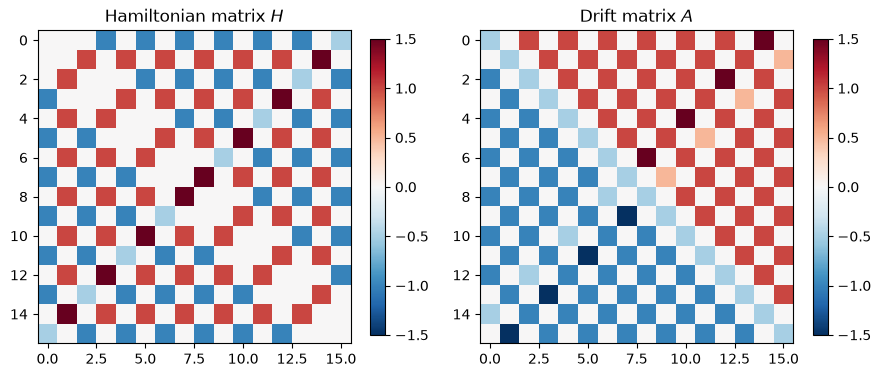

In [6]:
nodes = list(range(1, n_modes + 1))
node_index = {node: i for i, node in enumerate(nodes)}

adj = sum(on * r * np.exp(1j * th) * build_adj(edges, w, node_index, n_modes)
          for on, th, w in zip(group_on, theta, groups))
H = squeezing_hamiltonian(adj) + beam_splitter * beamsplitter_hamiltonian_allpairs(n_modes)

Omega = symplectic_form(n_modes)
C = np.kron(np.diag(np.sqrt(kappa)), np.array([[0, 1], [-1, 0]])).T
sigma_in = (2 * bath_n + 1) * np.eye(2 * n_modes)
sigma_m = generaldyne_cm(n_modes, s_meas, phi_meas)

A, D, B, E = sme_matrices(H, C, sigma_in, sigma_m)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, M, t in zip(ax, [H, A], ["Hamiltonian matrix $H$", "Drift matrix $A$"]):
    lim = np.abs(M).max()
    im = a.imshow(M, cmap="RdBu_r", vmin=-lim, vmax=lim)
    a.set_title(t)
    fig.colorbar(im, ax=a, shrink=0.8)
plt.tight_layout()

### 4.1 Steady-state conditional covariance

Solve the CARE and check the solution: residual of the Riccati equation, closed-loop
stability, and the uncertainty principle $\sigma+i\Omega\ge0$.

In [7]:
sigma_c = steady_conditional_cm(A, D, B, E)
sigma_u = steady_unconditional_cm(A, D)

print("max |Riccati residual|       :", np.abs(riccati_rhs(sigma_c, A, D, B, E)).max())
print("max Re eig(A)  (open loop)   :", np.linalg.eigvals(A).real.max())
print("max Re eig(Ã - σBBᵀ) (closed):", np.linalg.eigvals(A + E @ B.T - sigma_c @ B @ B.T).real.max())
print("min eig(σ + iΩ)              :", np.linalg.eigvalsh(sigma_c + 1j * Omega).min())
print("symplectic eigenvalues       :", symplectic_eigenvalues(sigma_c))
print("purity conditional / uncond. :", purity(sigma_c), "/", purity(sigma_u))
print("E_N modes 4–5 cond. / uncond.:", log_negativity(two_mode_cm(sigma_c, 6, 8)), "/",
      log_negativity(two_mode_cm(sigma_u, 6, 8)))

max |Riccati residual|       : 5.717648576819556e-15
max Re eig(A)  (open loop)   : -0.04126928367132447
max Re eig(Ã - σBBᵀ) (closed): -0.5024665573080591
min eig(σ + iΩ)              : -1.1670934105066216e-15
symplectic eigenvalues       : [1. 1. 1. 1. 1. 1. 1. 1.]
purity conditional / uncond. : 0.999999999999996 / 0.07802499238037229
E_N modes 4–5 cond. / uncond.: 0.4137543791683754 / 0.1345031319589506


The open-loop drift is stable, but only barely (slowest rate $\approx0.04\,\kappa$): the
squeezing almost outruns the damping. Without measurement the steady state is therefore
strongly **mixed** (purity $\approx0.08$). Heterodyne monitoring of a vacuum bath at unit
efficiency keeps the conditional state **pure** (all symplectic eigenvalues equal 1), and
it relaxes an order of magnitude faster (closed-loop rate $\approx0.5\,\kappa$). The
conditional mean keeps fluctuating (Sec. 4.3), but the shape of the Gaussian, and so all
its entanglement, is stationary.

log-negativity map:
 [[0.     0.0123 0.     0.     0.     0.     0.     0.4138]
 [0.0123 0.     0.     0.     0.     0.     0.3415 0.5212]
 [0.     0.     0.     0.     0.     0.3415 0.5212 0.    ]
 [0.     0.     0.     0.     0.4138 0.5212 0.     0.    ]
 [0.     0.     0.     0.4138 0.     0.0123 0.     0.    ]
 [0.     0.     0.3415 0.5212 0.0123 0.     0.     0.    ]
 [0.     0.3415 0.5212 0.     0.     0.     0.     0.    ]
 [0.4138 0.5212 0.     0.     0.     0.     0.     0.    ]]


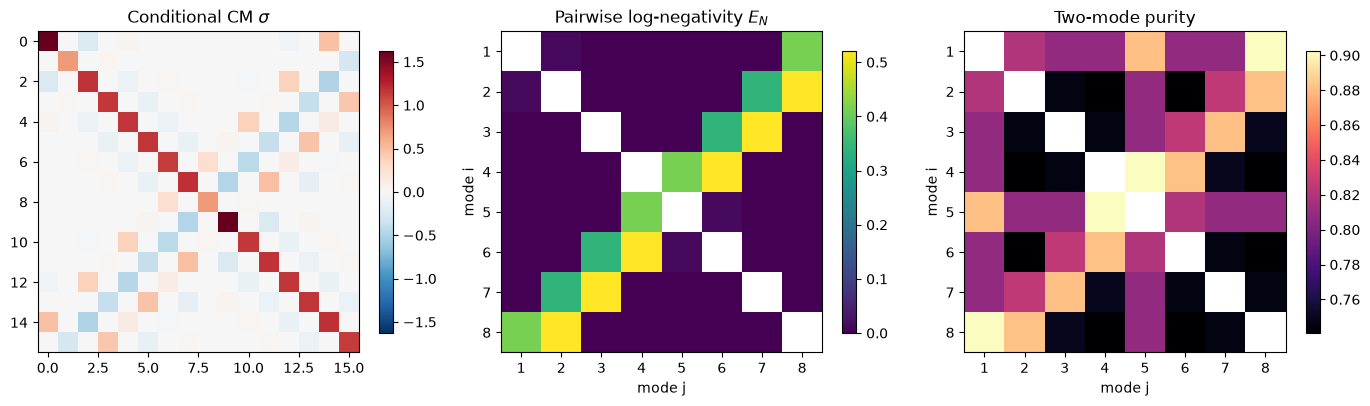

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
im = ax[0].imshow(sigma_c, cmap="RdBu_r", vmin=-np.abs(sigma_c).max(), vmax=np.abs(sigma_c).max())
ax[0].set_title(r"Conditional CM $\sigma$")
fig.colorbar(im, ax=ax[0], shrink=0.8)

LN = pairwise_map(sigma_c, log_negativity)
im = ax[1].imshow(LN, cmap="viridis", extent=[0.5, 8.5, 8.5, 0.5])
ax[1].set_title("Pairwise log-negativity $E_N$")
fig.colorbar(im, ax=ax[1], shrink=0.8)

PU = pairwise_map(sigma_c, purity)
im = ax[2].imshow(PU, cmap="magma", extent=[0.5, 8.5, 8.5, 0.5])
ax[2].set_title("Two-mode purity")
fig.colorbar(im, ax=ax[2], shrink=0.8)
for a in ax[1:]:
    a.set_xlabel("mode j"); a.set_ylabel("mode i")
    a.set_xticks(nodes); a.set_yticks(nodes)
plt.tight_layout()
fig.savefig("figures/steady_state_maps.png", dpi=150)
print("log-negativity map:\n", np.nan_to_num(LN))

### 4.2 Transient: integrating the Riccati equation

Starting from vacuum, $\sigma(t)$ relaxes to the CARE solution on the time scale
set by the closed-loop eigenvalues. This independently validates the algebraic solution.

final distance: 1.7886669922972942e-10


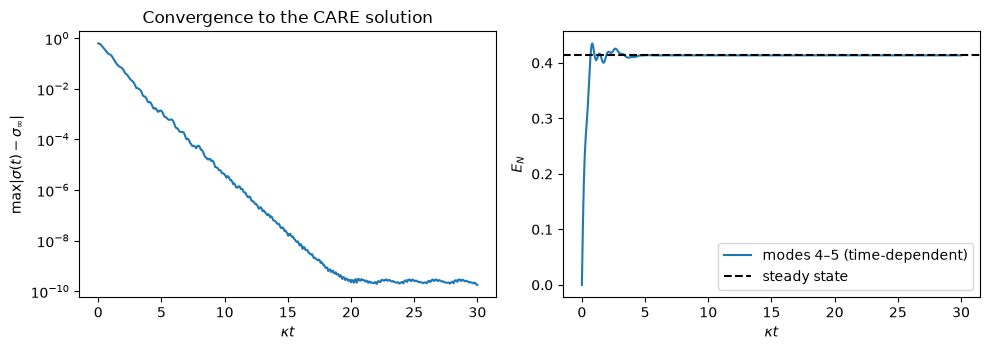

In [9]:
t, sig_t = riccati_trajectory(np.eye(2 * n_modes), A, D, B, E, t_max=30)
dist = np.abs(sig_t - sigma_c).max(axis=(1, 2))
EN45 = [log_negativity(two_mode_cm(s, 6, 8)) for s in sig_t]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].semilogy(t, dist)
ax[0].set_xlabel(r"$\kappa t$"); ax[0].set_ylabel(r"$\max|\sigma(t)-\sigma_\infty|$")
ax[0].set_title("Convergence to the CARE solution")
ax[1].plot(t, EN45, label="modes 4–5 (time-dependent)")
ax[1].axhline(log_negativity(two_mode_cm(sigma_c, 6, 8)), ls="--", c="k", label="steady state")
ax[1].set_xlabel(r"$\kappa t$"); ax[1].set_ylabel("$E_N$"); ax[1].legend()
plt.tight_layout()
fig.savefig("figures/riccati_transient.png", dpi=150)
print("final distance:", dist[-1])

### 4.3 A stochastic trajectory of the conditional mean

The conditional mean follows $d\bar r = A\bar r\,dt+(E-\sigma B)\,dW$. Here we integrate
one realisation with Euler–Maruyama, together with $\sigma(t)$ (forward Euler).
The mean diffuses with large, slow excursions (set by the weakly damped open-loop mode),
while $\sigma(t)$ converges to the deterministic steady state.

|σ(t_max) - σ_∞| from Euler integration: 6.800116025829084e-15


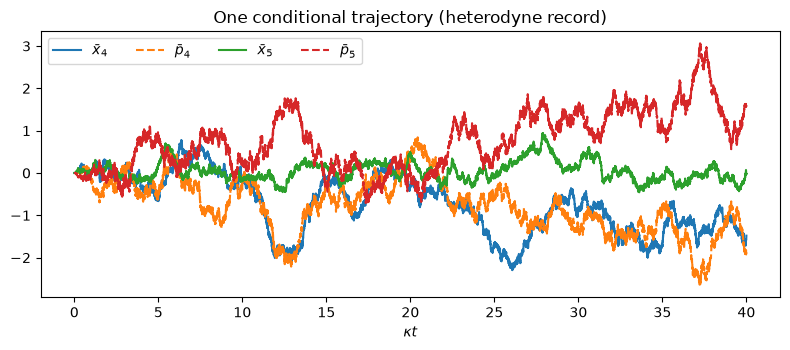

In [10]:
rng = np.random.default_rng(1)
tt, rs, sigma_end = mean_trajectory(np.zeros(2 * n_modes), np.eye(2 * n_modes),
                                    A, D, B, E, t_max=40, dt=2e-3, rng=rng)
print("|σ(t_max) - σ_∞| from Euler integration:", np.abs(sigma_end - sigma_c).max())

fig, ax = plt.subplots(figsize=(8, 3.6))
for m in [3, 4]:
    ax.plot(tt, rs[:, 2 * m], label=f"$\\bar x_{m+1}$")
    ax.plot(tt, rs[:, 2 * m + 1], label=f"$\\bar p_{m+1}$", ls="--")
ax.set_xlabel(r"$\kappa t$"); ax.legend(ncol=4)
ax.set_title("One conditional trajectory (heterodyne record)")
plt.tight_layout()
fig.savefig("figures/mean_trajectory.png", dpi=150)

### 4.4 Consistency check in a stable regime

Averaging over measurement records must give back the unconditional state. To get good
Monte-Carlo statistics we use a faster-relaxing configuration (squeezing $r=0.2$, no beam
splitter). The ensemble average over records must give back the unconditional state:
$\sigma_{\rm unc}=\sigma_c+\Sigma_{\bar r}$, where the covariance of the conditional mean solves
$A\Sigma+\Sigma A^T+(E-\sigma_cB)(E-\sigma_cB)^T=0$. We check this analytically and against
a long Monte-Carlo trajectory.

In [11]:
adj_s = 0.2 * build_adj(edges, groups[0], node_index, n_modes)
A_s, D_s, B_s, E_s = sme_matrices(squeezing_hamiltonian(adj_s), C, sigma_in, sigma_m)
print("max Re eig(A):", np.linalg.eigvals(A_s).real.max())

sc = steady_conditional_cm(A_s, D_s, B_s, E_s)
su = steady_unconditional_cm(A_s, D_s)
G = E_s - sc @ B_s
Sigma_r = solve_continuous_lyapunov(A_s, -G @ G.T)
print("analytic  |σ_unc - (σ_c + Σ_r)|:", np.abs(su - sc - Sigma_r).max())

_, rs_s, _ = mean_trajectory(np.zeros(2 * n_modes), sc, A_s, D_s, B_s, E_s,
                             t_max=2000, dt=5e-3, rng=np.random.default_rng(7))
Sigma_mc = np.cov(rs_s[2000:].T)
print("Monte-Carlo |Σ_r(MC) - Σ_r|       :", np.abs(Sigma_mc - Sigma_r).max(), " (max |Σ_r| =", np.abs(Sigma_r).max(), ")")
print("E_N modes 4–5: conditional", log_negativity(two_mode_cm(sc, 6, 8)),
      "| unconditional", log_negativity(two_mode_cm(su, 6, 8)))

max Re eig(A): -0.30000000000000004
analytic  |σ_unc - (σ_c + Σ_r)|: 5.273559366969494e-16


Monte-Carlo |Σ_r(MC) - Σ_r|       : 0.011001916785052706  (max |Σ_r| = 0.11344322904928983 )
E_N modes 4–5: conditional 0.5627020216047521 | unconditional 0.4854268271702419


The Monte-Carlo estimate agrees with $\Sigma_{\bar r}$ up to sampling error. Conditioning also
*increases* entanglement: the conditional state of modes 4–5 is more entangled than the
unconditional one, which is mixed by the output noise nobody records.

## 5. Comparison with the original script

The original `riccatiequation.py` called `solve_continuous_are(Ã, …)` instead of
`solve_continuous_are(Ã.T, …)`. That returns the stationary covariance for the drift
$\tilde A^T$, i.e. $\Omega H\to -H\Omega$, which (for this model) flips the sense of the
beam-splitter coupling while leaving the squeezing unchanged. The cell below shows that this matrix does **not** satisfy the Riccati equation
of the model, and how much the entanglement map changes. (The original `takeSub` also had
an index typo in its third row, `CM[j, j+1]` instead of `CM[j, i+1]`; it is replaced here
by `two_mode_cm`.)

In [12]:
At = A + E @ B.T
sigma_old = np.real(solve_continuous_are(At, B, D - E @ E.T, np.eye(B.shape[1]), balanced=True))
print("residual (original solution):", np.abs(riccati_rhs(sigma_old, A, D, B, E)).max())
print("residual (this notebook)    :", np.abs(riccati_rhs(sigma_c, A, D, B, E)).max())
print("max |σ_old - σ|             :", np.abs(sigma_old - sigma_c).max())
print("max |ΔE_N| over pairs       :", np.nanmax(np.abs(pairwise_map(sigma_old, log_negativity) - LN)))

residual (original solution): 1.3512228201713985
residual (this notebook)    : 5.717648576819556e-15
max |σ_old - σ|             : 0.4440306027418002
max |ΔE_N| over pairs       : 0.5212340887920572


## 6. Optional: experimental covariance matrix

The original script also checked $\det\sigma_{jk}$ of the off-diagonal $2\times2$ blocks of a
measured covariance matrix. Point `exp_file` at a `.mat` file with a `V_clean` entry to run it.

In [13]:
import scipy.io

exp_file = Path("~/cluster/cleanmats/V_clean_0.mat").expanduser()

def offdiag_block_dets(CM):
    n = CM.shape[0] // 2
    out = np.full((n, n), np.nan)
    for j in range(n):
        for k in range(n):
            if j != k:
                out[j, k] = np.linalg.det(CM[2 * j:2 * j + 2, 2 * k:2 * k + 2])
    return out

print("theory  det(σ_jk):\n", offdiag_block_dets(sigma_c))
if exp_file.exists():
    print("experiment det(σ_jk):\n", offdiag_block_dets(scipy.io.loadmat(exp_file)["V_clean"]))
else:
    print(f"(no experimental file at {exp_file}; skipped)")

theory  det(σ_jk):
 [[    nan -0.006   0.0003 -0.     -0.     -0.      0.0001 -0.1286]
 [-0.006      nan  0.0105  0.0006 -0.     -0.0005 -0.1391 -0.2161]
 [ 0.0003  0.0105     nan  0.0105  0.0001 -0.1391 -0.2166 -0.0165]
 [-0.      0.0006  0.0105     nan -0.1286 -0.2161 -0.0165 -0.0003]
 [-0.     -0.      0.0001 -0.1286     nan -0.006   0.0003 -0.    ]
 [-0.     -0.0005 -0.1391 -0.2161 -0.006      nan  0.0105  0.0006]
 [ 0.0001 -0.1391 -0.2166 -0.0165  0.0003  0.0105     nan  0.0105]
 [-0.1286 -0.2161 -0.0165 -0.0003 -0.      0.0006  0.0105     nan]]
experiment det(σ_jk):
 [[    nan -0.     -0.     -0.      0.     -0.      0.     -0.    ]
 [-0.         nan -0.0024  0.     -0.2826  0.0277 -0.2556 -0.    ]
 [-0.     -0.0024     nan -0.2906  0.0002 -0.2878  0.0263 -0.3252]
 [-0.      0.     -0.2906     nan -0.3112  0.0012 -0.3728  0.0251]
 [ 0.     -0.2826  0.0002 -0.3112     nan -0.4054  0.0005 -0.001 ]
 [-0.      0.0277 -0.2878  0.0012 -0.4054     nan -0.0013  0.0007]
 [ 0.     -0.2556 